# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt # importar librerías

In [2]:
# cargar archivos
df_plans = pd.read_csv('/datasets/plans.csv')
df_users = pd.read_csv('/datasets/users_latam.csv') #completa el código
df_usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [3]:
df_plans.head(5)# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
df_users.head(5)# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
df_usage.head(5)# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("df_plans", df_plans.shape)
print("df_users", df_users.shape)
print("df_usage", df_usage.shape)

df_plans (2, 8)
df_users (4000, 8)
df_usage (40000, 6)


In [7]:
df_plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
df_users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
df_usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(df_users.isna().sum())# Cantidad de valores nulos)
print(df_users.isna().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
print(df_usage.isna().sum())# Cantidad de valores nulos)
print(df_usage.isna().mean())# Proporción de valores nulos)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  el dataframe users tiene 469 valores nulos que corresponden al 11.7% lo dejo como nulo o no identificado y 3534 valores nulos en la churn date que corresponde al 88% lo ignoro se podria tomar como que los clientes no han realizado la cancelación y están activos.

  el dataframe usage tiene 50 valores nulos en date 1.25% se puede promediar , tiene 22076 para duration con el 55% y 17896 con 44.7% para length los ignoro porque este resultado debería estar relacionado que duration en solo para llamadas telefonicas y length solo para texto
  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
col_numerics_df_users= ["user_id","age"]
df_users[col_numerics_df_users].describe()# explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
  Los valores de user_id se encuentran dentro de un rango consecutivo entre 10000 y 13999. No se observan valores inválidos ni anomalías aparentes
- La columna `age` ...
  tiene un sentinel de -999 lo cual es un error ya que este número no es una edad mínima 

In [13]:
col_numerics_df_usage= ["id","user_id"]
df_usage[col_numerics_df_usage].describe()# explorar columnas numéricas de usage

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- En las columnas respectivas , No se detectan valores inválidos ni sentinels en estas variables.

In [14]:
# explorar columnas categóricas de users
columnas_df_users = ['city', 'plan']
df_users[columnas_df_users].describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` tiene 3531 registros con la data de las ciudades con valores nulos de 469 hay 7 ciudades unicas, encabezando Bogotá con 808 registros
- La columna `plan` tiene 4000 registros es decir no hay valores faltantes , hay 2 planes unicos principalmente el básico con 2595 registros

In [15]:
# explorar columna categórica de usage
columnas_df_usage = ['type']
df_usage[columnas_df_usage].describe() # completa el código

,type
count,40000
unique,2
top,text
freq,22092


- La columna `type` tiene 40000 registros, no hay valores faltantes , tiene 2 unicas categorias siendo la más frecuente text con 22092 registros


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 
En las columnas analizadas se evidenció un sentinel en la columna 'age' del df_users -999 , se reemplazaria por la mediana ya que permite conservar una distribución general sin introducir sesgos importantes en el análisis
**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
df_users['reg_date'] = pd.to_datetime(
    df_users['reg_date'],
    errors='coerce'
)# completa el código

In [17]:
# Convertir a fecha la columna `date` de usage
df_usage['date'] = pd.to_datetime(
    df_usage['date'],
    errors='coerce'
)# completa el código

In [18]:

# Revisar los años presentes en `reg_date` de users
df_users['reg_date'].dt.year.value_counts().sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, teniendo en cuenta que los datos registrados son hasta el 2024 , se deben revisar los 40 registros que se reflejan en 2026

In [19]:
# Revisar los años presentes en `date` de usage
df_usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, los registros son correctos ya que corresponden al 2024 hay 39950 por lo que se identifican 50 valores nulos
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:
los 40 registros del 2026 identificados en el df_users en la colomna reg_date la recomendación es convertir estos valores a nulos para fines del análisis 2024. 
Por otro lado los 50 valores identificados en el df_usage en la columna date se pueden mantener como nulos o se podrian promediar
**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = df_users["age"].median()
df_users['age'] = df_users["age"].replace(-999,age_mediana).astype (int)

# Verificar cambios
df_users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
df_users['city']=df_users['city'].replace('?',pd.NA)
df_users['city']=df_users['city'].fillna(pd.NA)

# Verificar cambios
df_users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
df_users.loc[df_users['reg_date'].dt.year > 2024,
    'reg_date'] =pd.NaT


# Verificar cambios
df_users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
df_usage['duration'].isna().groupby(df_usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
df_usage['length'].isna().groupby(df_usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
valida el df_usage para la columna duration y length se evidencia que ambas son MAR ya que depeden de la columna type por lo que la columna duration para type call tiene 0 nulos y la columna length para type text tiene 0 nulos la medición correcta para cada uno.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
df_usage["is_text"] = (df_usage["type"] == "text").astype(int) #conocer el total de mensajes
df_usage["is_call"] = (df_usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario y renombrar las columnas
usage_agg =  ( df_usage
    .groupby("user_id")
    .agg(
        cant_mensajes=("is_text", "sum"),
        cant_llamadas=("is_call", "sum"),
        cant_minutos_llamada=("duration", "sum")
    )
    .reset_index()
)

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(df_users,usage_agg, on='user_id',how='left')

#se añadieron estos comandos ya que estas 2 columnas se reflejaban con decimal
user_profile['cant_mensajes'] = (
    user_profile['cant_mensajes']
    .fillna(0)
    .astype(int)
)

user_profile['cant_llamadas'] = (
    user_profile['cant_llamadas']
    .fillna(0)
    .astype(int)
)
    
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [27]:
# Resumen estadístico de las columnas numéricas
cols_numericas = ['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']
user_profile[cols_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,3999.000000
mean,48.122250,5.523000,4.477000,23.317054
std,17.690408,2.359738,2.145139,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [28]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

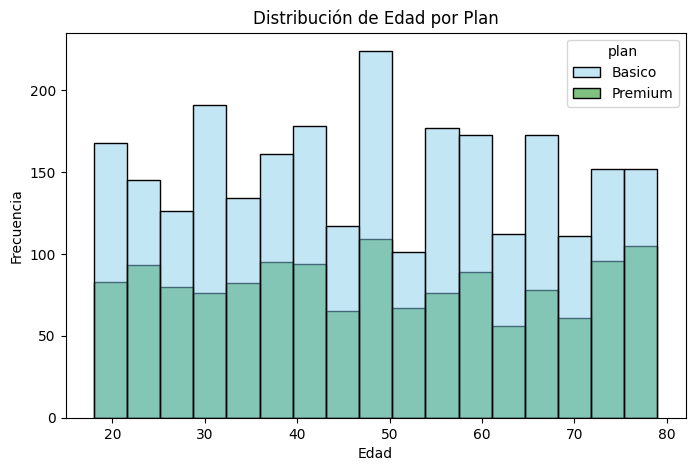

In [29]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue','green'],
    bins=17
)

plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- la Distribución es asimetrica positiva con una presencia mayoritaria en el plan premium en la edad máxima representada hasta 80 años , el plan básico tiene mayor concentración entre los 20 y 45 años 

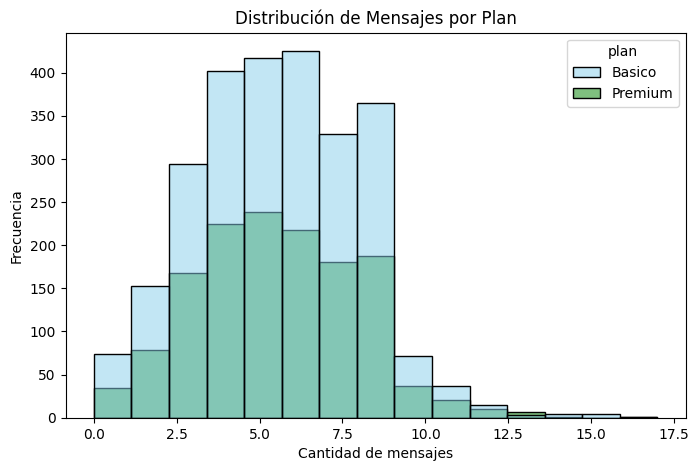

In [30]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue','green'],
    bins=15
)

plt.title('Distribución de Mensajes por Plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución es bimodal con 2 grupos de usuarios con comportamientos distintos evidente en el plan básico uno entre 3 y 6 mensajes y el otro ente 6.5 y 9 mensajes , el plan premium muestra un comportamiento homogeneo , el pico máximo global se da entre 5 y 6 mensajes en ambos planes.

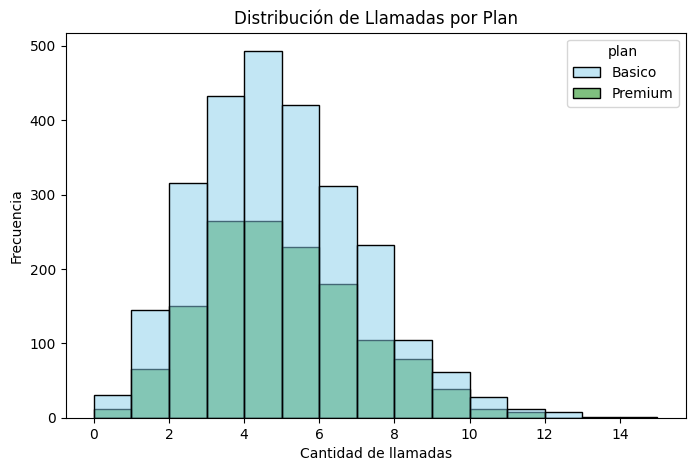

In [31]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue','green'],
    bins=15
)

plt.title('Distribución de Llamadas por Plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La Distribución está sesgada a la derecha asimétrica positiva , el plan básico tiene mayor demanda de llamadas lo que indica que es el plan que más eligen los usuarios para llamadas , ambos planes tienen pocos usuarios a partir de las 10 llamadas.

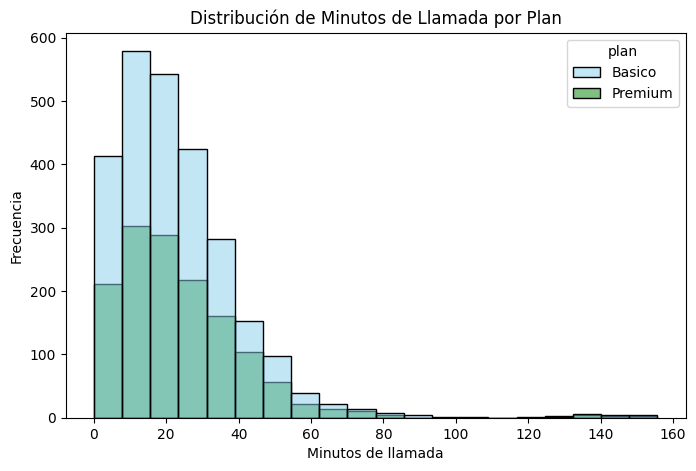

In [32]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue','green'],
    bins=20
)

plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La Distribución está fuertemente inclinada hacia la derecha , el pico máximo global para ambos planes está entre 10 y 20 minutos después de los 30 minutos hay una caida en el número de llamadas en ambos planes , entre 140 y 160 minutos se evidencia que pocos usarios hacen llamadas prolongadas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

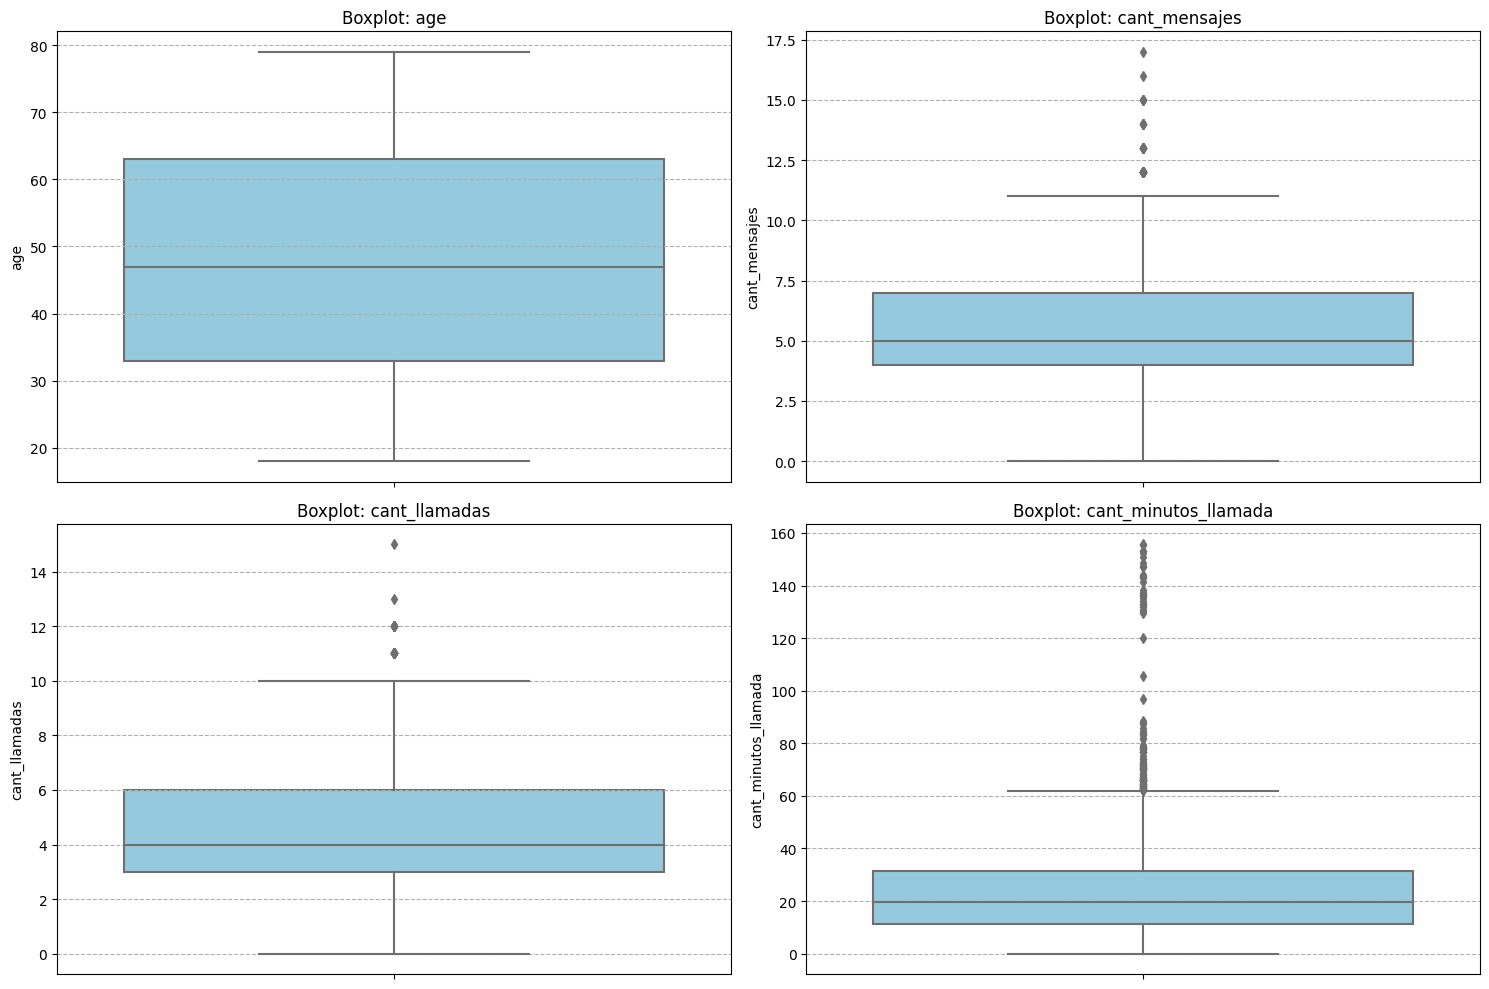

In [33]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


# Bucle 
plt.figure(figsize=(15, 10))
for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=user_profile[col], color='skyblue') 
    plt.title(f'Boxplot: {col}')
    plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()

💡Insights: 
- Age: sin outliers 
- cant_mensajes: con outliers
- cant_llamadas: con outliers
- cant_minutos_llamada: con outliers

In [34]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print ('--Análisis de límites método IQR--')
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f'\n{col}')
    print(f'Limite inferior: {limite_inferior:.2f}')
    print(f'Limite superior: {limite_superior:.2f}')
    print(f"  > Q1: {Q1} | Q3: {Q3} | IQR: {IQR}")

    outliers = user_profile[
        (user_profile[col] < limite_inferior) |
        (user_profile[col] > limite_superior)
    ]

    print(f'Cantidad de outliers: {len(outliers)}')

    


--Análisis de límites método IQR--

cant_mensajes
Limite inferior: -0.50
Limite superior: 11.50
  > Q1: 4.0 | Q3: 7.0 | IQR: 3.0
Cantidad de outliers: 46

cant_llamadas
Limite inferior: -1.50
Limite superior: 10.50
  > Q1: 3.0 | Q3: 6.0 | IQR: 3.0
Cantidad de outliers: 30

cant_minutos_llamada
Limite inferior: -19.32
Limite superior: 61.86
  > Q1: 11.12 | Q3: 31.415 | IQR: 20.295
Cantidad de outliers: 109


In [35]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

# Insights
#cant_mensajes :46 outliers identificados con un límite superior de 11.50 sin embargo evidenciamos que el valor 
#máximo es de 17 por lo que se puede mantener ya que esta diferencia es mínima

# cant_llamadas :30 outliers se puede deber a un pequeño grupo de usuarios con una frecuencia de llamadas considerablemente 
#superior al resto por lo que se pueden mantener

#cant_minutos_llamada:109 outliers , es la variable con la mayor cantidad dde valores extremos sin embargo muestra un valor 
#máximo de 155.69 se podría mantener si se toman como un rango de clientes de alto consumo

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000
mean,5.523000,4.477000,23.317054
std,2.359738,2.145139,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [36]:
# Crear columna grupo_uso

import numpy as np
condiciones = [
    (user_profile['cant_llamadas'] < 5) &
    (user_profile['cant_mensajes'] < 5),

    (user_profile['cant_llamadas'] < 10) &
    (user_profile['cant_mensajes'] < 10)
]

grupos = [
    'Bajo uso',
    'Uso medio'
]

user_profile['grupo_uso'] = np.select(
    condiciones,
    grupos,
    default='Alto uso'
)

user_profile[['cant_llamadas',
              'cant_mensajes',
              'grupo_uso']].head()

,cant_llamadas,cant_mensajes,grupo_uso
0,3,7,Uso medio
1,10,5,Alto uso
2,2,5,Uso medio
3,3,11,Alto uso
4,3,4,Bajo uso


In [37]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [38]:
# Crear columna grupo_edad
import numpy as np

condiciones = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

grupos = [
    'Joven',
    'Adulto'
]

user_profile['grupo_edad'] = np.select(
    condiciones,
    grupos,
    default='Adulto Mayor'
)

user_profile[['age', 'grupo_edad']].head()

,age,grupo_edad
0,38,Adulto
1,53,Adulto
2,57,Adulto
3,69,Adulto Mayor
4,63,Adulto Mayor


In [39]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

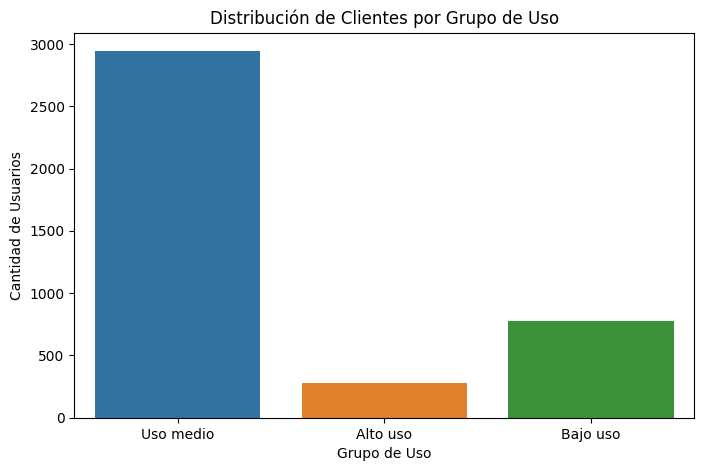

In [40]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8,5))

sns.countplot(
    data=user_profile,
    x='grupo_uso'
)

plt.title('Distribución de Clientes por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.show()

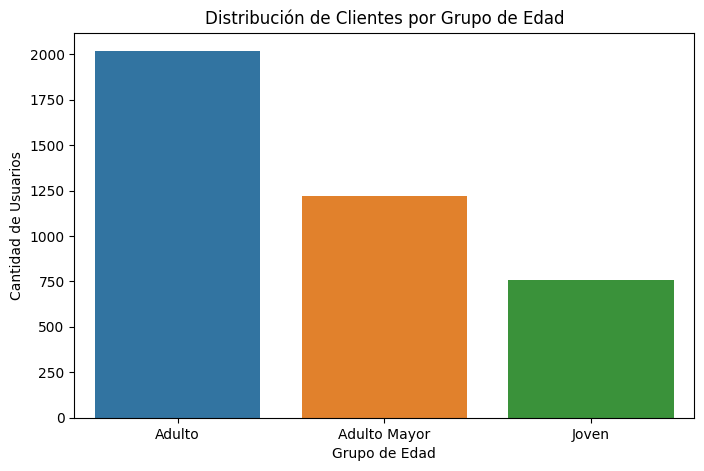

In [41]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8,5))

sns.countplot(
    data=user_profile,
    x='grupo_edad'
)

plt.title('Distribución de Clientes por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

El objetivo del análisis es evaluar el uso de los clientes de los servicios moviles (llamadas y mensajes de texto) para la empresa Connecta Tel identificando patrones de uso , comportamientos átipicos y evidenciar que segmentos de clientes muestran necesidades diferenciadas para optimizar la estrategia comercial.
Evaluamos 4000 clientes hasta el año 2024.



⚠️ **Problemas detectados en los datos**

- Se corrigieron valores atípicos (sentinel -999) en la variable de edad y se marcaron como nulos los registros futuros (2026), ajustándolos a la ventana real de análisis.

- Validación de variables: Se determinó que los valores nulos en duration y length son inherentes a la naturaleza del servicio y no errores de registro. Asimismo, los valores extremos en el consumo fueron validados como comportamientos legítimos de usuarios de alto valor.

- Para la columna city los sentinels que correspondian al 13% y fueron reemplazados por valores nulos


🔍 **Segmentos por Edad**
- Usuarios jóvenes (menores de 30 años): presentan una mayor actividad en el envío de mensajes y un uso moderado del servicio de llamadas.
- Usuarios adultos (entre 30 y 55 años): muestran un comportamiento equilibrado entre llamadas y mensajes, siendo el grupo con el patrón de consumo más estable.
- Usuarios mayores (más de 55 años): registran una menor utilización de mensajes y una mayor preferencia por las llamadas, aunque con una frecuencia de uso más baja en comparación con otros segmentos.


📊 **Segmentos por Nivel de Uso**
El análisis permitió identificar dos grupos de clientes con alto potencial para la generación de ingresos y la implementación de estrategias de fidelización:

- Adultos con nivel de uso medio y alto: se caracterizan por mantener patrones de consumo estables y predecibles, lo que los convierte en clientes con menor riesgo de cancelación y alta compatibilidad con planes mensuales recurrentes.
- Usuarios jóvenes de alto uso: destacan por una elevada actividad en mensajería y un consumo intensivo de los servicios. Este segmento representa una oportunidad para impulsar planes digitales, paquetes ilimitados y ofertas personalizadas, además de contar con un importante potencial de crecimiento a largo plazo.

**Outliers y su Impacto en el Negocio**

El análisis de valores atípicos permitió identificar un grupo reducido de usuarios con niveles de consumo significativamente superiores al promedio de la base de clientes.

En el servicio de llamadas se observaron usuarios con consumos cercanos a los 155 minutos mensuales, muy por encima del comportamiento habitual de la mayoría de los clientes.
De igual manera, se detectaron usuarios con una cantidad de mensajes y llamadas considerablemente superior al promedio, concentrando una proporción relevante del tráfico total de la red.

***Implicaciones para el negocio***

La presencia de estos usuarios de alto consumo puede representar tanto oportunidades como riesgos para la compañía:

Si permanecen en planes que no corresponden a su nivel de uso, podrían generar mayores costos operativos y una experiencia menos satisfactoria debido a cobros por excedentes.
Estos clientes podrían constituir un segmento de alto valor que actualmente no está siendo atendido con ofertas adecuadas a sus necesidades de consumo.
También es posible que algunos casos correspondan a líneas compartidas entre varios usuarios o a clientes corporativos que están siendo gestionados bajo planes diseñados para usuarios individuales.


💡 **Recomendaciones**
- Los usuarios identificados como de consumo extremo representan un segmento estratégico para ConnectaTel. Su análisis y monitoreo permitirían optimizar la segmentación comercial, diseñar planes más adecuados a sus necesidades y aumentar la rentabilidad mediante estrategias específicas de fidelización y migración hacia productos de mayor valor.
- Los resultados sugieren que la edad influye en la preferencia por determinados servicios de comunicación, mientras que la intensidad de uso permite identificar segmentos con diferentes necesidades y potencial comercial. Esta segmentación facilita el diseño de estrategias más precisas para retención, fidelización y generación de valor para la compañía.
- Implementar estrategias de fidelización para los clientes que están segmentados entre Adultos mayores y Adultos ya que corresponden a la mayoria
- Bogotá y Mexico son las ciudades con mayor cantidad de clientes por lo que se recomienda replicar la estrategia de marketing en otras ciudades con potencial como Cali.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`